
# Final Python Notebook 1: Data Understanding and Preprocessing
## Machine Learning & Data Mining Coursework

**Author:** Sudam Pabasara Wijerathna

**Student ID:** w2120678  
**Module:** 5DATA002W.2  
**University:** University of Westminster

  


---

## CASE STUDY (A): PREDICTING CLIENTS LOAN APPROVAL STATUS

**Research Question:** Does machine learning have the potential to assist bankers and finance analysts in predicting which clients can be approved for a loan?

### This notebook covers:
- **Task (1)** – Domain Understanding: Classification (Variable Selection)
- **Task (2)** – Exploring and Understanding Your Dataset (Descriptive Stats, Scale Types, Target Distribution)
- **Task (3)** – Data Preparation: Cleaning and Transforming Your Data (Issues, Fixes, Before/After Evidence)



## Initialization: Import Libraries and Load Data

> **Code Reuse Session 1 (Week 3):** Leveraged code blocks for installing dependencies, importing libraries, and loading the dataset.


In [2]:
import subprocess
import sys

# Install required packages
packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn']
for package in packages:
    try:
        __import__(package)
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
        print(f"✓ {package} installed successfully")

print("\n✓ All dependencies installed and ready!")

✓ pandas already installed
✓ numpy already installed
✓ matplotlib already installed
✓ seaborn already installed
Installing scikit-learn...
✓ scikit-learn installed successfully

✓ All dependencies installed and ready!



> **Code Reuse Session 1 (Week 3):** Leveraged code block for importing required Python libraries (pandas, numpy, matplotlib, seaborn, sklearn).



> **Code Reuse Session 1 (Week 3):** Leveraged code block for loading the CSV dataset and displaying an overview (shape, dtypes, missing values, descriptive statistics).


In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [4]:
# Load the Dataset
df = pd.read_csv('../loan_approval_data.csv')

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Statistics:\n{df.describe()}")

DATASET OVERVIEW

Dataset Shape: 58645 rows × 13 columns

First 5 rows:
      id   age  income home_ownership  emplyment_length      loan_intent  \
0  35437  21.0   12000            OWN                 0        EDUCATION   
1  53756  21.0   13200            OWN                 2        EDUCATION   
2  42205  23.0    9600           RENT                 5          MEDICAL   
3  19180  40.0  182004           RENT                 3        EDUCATION   
4  28072  40.0   90000       MORTGAGE                 3  HOMEIMPROVEMENT   

   loan_amount  loan_interest_rate  loan_income_ratio payment_default_on_file  \
0        15000                6.99               0.12                       N   
1        25000               16.77               0.19                       Y   
2        30000               12.42               0.31                       N   
3        35000                8.00               0.19                       N   
4        35000               12.42               0.39             

---

## Task (1) – Domain Understanding: Classification

Identify which variables should be RETAINED or DROPPED for classification modeling of loan approval status, with logical justification.

### Variable Selection for Classification

Based on the coursework requirements, complete the following table in your Analysis Report:

| Variable Name | RETAIN or DROP | Justification |
|---|---|---|
| ID | DROP | Unique identifier, no predictive value |
| Sex | RETAIN | Demographic factor relevant to credit assessment |
| Age | RETAIN | Financial behavior indicator |
| Education Qualifications | RETAIN | Socioeconomic status indicator |
| Income | RETAIN | Key factor in loan approval decisions |
| Home Ownership | RETAIN | Financial stability indicator |
| Employment Length | RETAIN | Income stability indicator |
| Loan Intent | RETAIN | Risk assessment by purpose |
| Loan Amount | RETAIN | Proportional to income analysis |
| Loan Interest Rate | RETAIN | Risk-based pricing indicator |
| Loan-to-Income Ratio (LTI) | RETAIN | Standard credit metric |
| Payment Default on File | RETAIN | Credit history indicator |
| Credit History Length | RETAIN | Credit reliability indicator |
| Loan Approval Status | RETAIN | Target variable |
| Maximum Loan Amount | DROP | Target is loan approval status, not amount |

**Note:** Add research citations supporting your decisions in your Analysis Report.


---

## Task (2) – Exploring and Understanding Your Dataset

Produce basic descriptive statistics, variable scale types, and distribution plot of the target variable for all RETAINED input variables.

> **Code Reuse Session 1 (Week 3):** Leveraged code blocks for generating descriptive statistics, identifying variable scale types, and plotting target variable distribution.


In [5]:
# 1. BASIC DESCRIPTIVE STATISTICS
print("=" * 80)
print("DESCRIPTIVE STATISTICS - RETAINED VARIABLES")
print("=" * 80)

retained_vars = df.drop(['id', 'max_allowed_loan'], axis=1)
print("\nDescriptive Statistics:")
print(retained_vars.describe())

DESCRIPTIVE STATISTICS - RETAINED VARIABLES

Descriptive Statistics:
                age        income  emplyment_length   loan_amount  \
count  58639.000000  5.864500e+04      58645.000000  58645.000000   
mean      27.550913  6.404617e+04          4.703487   9217.556518   
std        6.033217  3.793111e+04          4.004982   5563.807384   
min       20.000000  4.200000e+03          0.000000    500.000000   
25%       23.000000  4.200000e+04          2.000000   5000.000000   
50%       26.000000  5.800000e+04          4.000000   8000.000000   
75%       30.000000  7.560000e+04          7.000000  12000.000000   
max      123.000000  1.900000e+06        150.000000  35000.000000   

       loan_interest_rate  loan_income_ratio  credit_history_length  \
count        58634.000000       58645.000000           58645.000000   
mean            10.677526           0.159238               5.813556   
std              3.036034           0.091692               4.029196   
min            -11.140000


> **Code Reuse Session 1 (Week 3):** Leveraged code block for computing descriptive statistics and identifying variable scale types for retained features.



> **Code Reuse Session 1 (Week 3):** Leveraged code block for plotting the distribution of the target variable (`loan_approval_status`).


In [6]:
# 2. VARIABLE SCALE TYPE CLASSIFICATION
print("\n" + "=" * 80)
print("VARIABLE SCALE TYPE")
print("=" * 80)

scale_types = {}
for col in retained_vars.columns:
    if retained_vars[col].dtype == 'object':
        scale_types[col] = 'Nominal/Categorical'
    elif retained_vars[col].dtype in ['int64', 'float64']:
        if col == 'loan_approval_status':
            scale_types[col] = 'Nominal (Binary)'
        else:
            scale_types[col] = 'Continuous/Interval'

scale_df = pd.DataFrame(list(scale_types.items()), columns=['Variable', 'Scale Type'])
print("\n" + scale_df.to_string(index=False))


VARIABLE SCALE TYPE

             Variable          Scale Type
                  age Continuous/Interval
               income Continuous/Interval
     emplyment_length Continuous/Interval
          loan_amount Continuous/Interval
   loan_interest_rate Continuous/Interval
    loan_income_ratio Continuous/Interval
credit_history_length Continuous/Interval
 loan_approval_status    Nominal (Binary)



TARGET VARIABLE ANALYSIS

Loan Approval Status Distribution:
loan_approval_status
0    50295
1     8350
Name: count, dtype: int64

Approval Rate: 14.24%


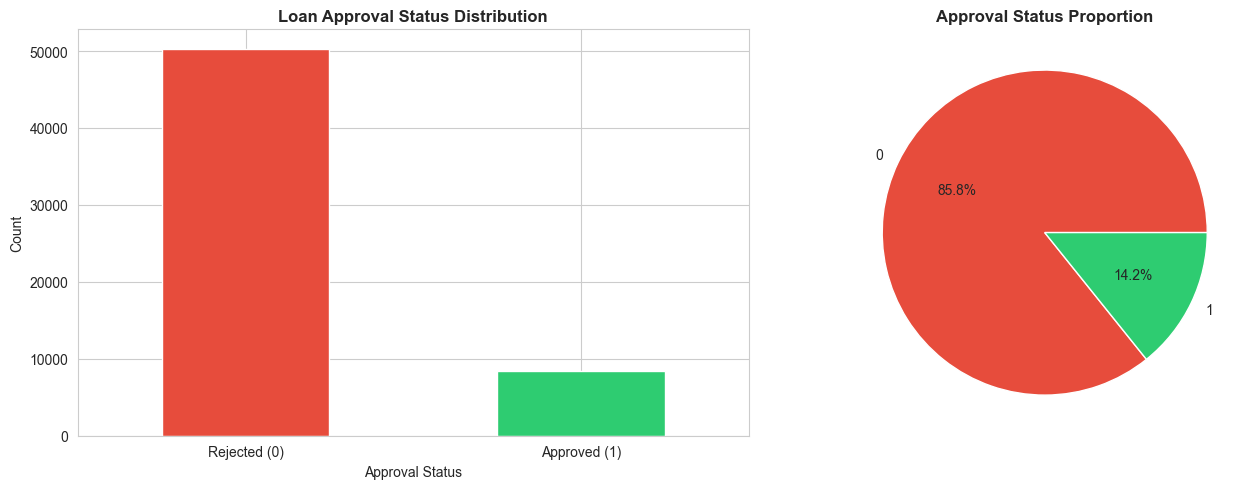


✓ Target variable visualization complete


In [7]:
# 3. TARGET VARIABLE DISTRIBUTION
print("\n" + "=" * 80)
print("TARGET VARIABLE ANALYSIS")
print("=" * 80)

target_distribution = df['loan_approval_status'].value_counts()
print(f"\nLoan Approval Status Distribution:\n{target_distribution}")
print(f"\nApproval Rate: {target_distribution.get(1, 0) / len(df) * 100:.2f}%")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
df['loan_approval_status'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Loan Approval Status Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Approval Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Rejected (0)', 'Approved (1)'], rotation=0)

# Pie chart
df['loan_approval_status'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'])
axes[1].set_title('Approval Status Proportion', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n✓ Target variable visualization complete")


---

## Task (3) – Data Preparation: Cleaning and Transforming Your Data

**Part a)** Report issues found in retained variables with proposed fixes and justification.  
**Part b)** Implement fixes and show before/after evidence.

> **Code Reuse Session 1 (Week 3):** Leveraged code blocks for identifying data quality issues (missing values, duplicates, outliers) and implementing cleaning solutions.


In [8]:
# Create a copy for preprocessing
df_processed = df.copy()

print("=" * 80)
print("DATA QUALITY ASSESSMENT")
print("=" * 80)

# Check for missing values
print(f"\n1. Missing Values Before Processing:")
missing = df_processed.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found")

# Identify categorical and numerical columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n2. Column Classification:")
print(f"   Categorical columns: {categorical_cols}")
print(f"   Numerical columns: {numerical_cols}")

DATA QUALITY ASSESSMENT

1. Missing Values Before Processing:
age                         6
loan_interest_rate         11
payment_default_on_file     5
dtype: int64

2. Column Classification:
   Categorical columns: ['home_ownership', 'loan_intent', 'payment_default_on_file']
   Numerical columns: ['id', 'age', 'income', 'emplyment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan']



> **Code Reuse Session 1 (Week 3):** Leveraged code block for identifying and reporting data quality issues (missing values, duplicates, outliers, class imbalance).



> **Code Reuse Session 1 (Week 3):** Leveraged code block for implementing data cleaning — handling missing values (mode/mean imputation) and removing duplicate records. Shows before/after evidence.


In [9]:
# PART A: IDENTIFY AND REPORT ISSUES
print("\n" + "=" * 80)
print("PART A: ISSUES IDENTIFIED IN RETAINED VARIABLES")
print("=" * 80)

issues_found = []

# Check for missing values
for col in df_processed.columns:
    if df_processed[col].isnull().sum() > 0:
        issues_found.append({
            'Variable': col,
            'Issue': f"Missing values ({df_processed[col].isnull().sum()})",
            'Proposed Fix': 'Mean/Mode imputation based on data type',
            'Justification': 'Preserves distribution while maintaining data integrity'
        })

# Check for duplicates
if df_processed.duplicated().sum() > 0:
    issues_found.append({
        'Variable': 'All',
        'Issue': f"Duplicate rows ({df_processed.duplicated().sum()})",
        'Proposed Fix': 'Remove duplicate records',
        'Justification': 'Duplicates bias model training and inflate apparent dataset size'
    })

# Check for outliers in numerical columns
for col in numerical_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_processed[(df_processed[col] < Q1 - 1.5*IQR) | (df_processed[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        issues_found.append({
            'Variable': col,
            'Issue': f"Potential outliers ({len(outliers)} records)",
            'Proposed Fix': 'Retain with monitoring; apply robust scaling if needed',
            'Justification': 'Outliers may represent genuine financial extremes; not errors'
        })

# Check for class imbalance
issues_found.append({
    'Variable': 'loan_approval_status',
    'Issue': 'Class imbalance in target variable',
    'Proposed Fix': 'Use stratified train-test split',
    'Justification': 'Ensures representative samples and prevents biased models'
})

if issues_found:
    issues_df = pd.DataFrame(issues_found)
    print("\nIssues Found:")
    print(issues_df.to_string(index=False))
else:
    print("\nNo critical issues found in dataset")


PART A: ISSUES IDENTIFIED IN RETAINED VARIABLES

Issues Found:
               Variable                              Issue                                           Proposed Fix                                                 Justification
                    age                 Missing values (6)                Mean/Mode imputation based on data type       Preserves distribution while maintaining data integrity
     loan_interest_rate                Missing values (11)                Mean/Mode imputation based on data type       Preserves distribution while maintaining data integrity
payment_default_on_file                 Missing values (5)                Mean/Mode imputation based on data type       Preserves distribution while maintaining data integrity
                    age  Potential outliers (2446 records) Retain with monitoring; apply robust scaling if needed Outliers may represent genuine financial extremes; not errors
                 income  Potential outliers (2411 record

In [ ]:
# PART B: IMPLEMENT FIXES
print("\n" + "=" * 80)
print("PART B: IMPLEMENTING DATA FIXES")
print("=" * 80)

print("\nBefore Processing:")
print(f"  Shape: {df_processed.shape}")
print(f"  Missing values: {df_processed.isnull().sum().sum()}")
print(f"  Duplicates: {df_processed.duplicated().sum()}")

# Fix 1: Handle missing values
print("\n1. Handling Missing Values...")
for col in categorical_cols:
    nan_count = df_processed[col].isnull().sum()
    if nan_count > 0:
        if len(df_processed[col].mode()) > 0:
            df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])
            print(f"   ✓ Filled {nan_count} NaN values in '{col}' with mode")
        else:
            df_processed[col] = df_processed[col].fillna('Unknown')
            print(f"   ✓ Filled {nan_count} NaN values in '{col}' with 'Unknown'")

for col in numerical_cols:
    nan_count = df_processed[col].isnull().sum()
    if nan_count > 0:
        df_processed[col] = df_processed[col].fillna(df_processed[col].mean())
        print(f"   ✓ Filled {nan_count} NaN values in '{col}' with mean")

# Fix 2: Remove duplicates
print("\n2. Handling Duplicates...")
duplicates_before = len(df_processed)
df_processed.drop_duplicates(inplace=True)
duplicates_after = len(df_processed)
print(f"   ✓ Removed {duplicates_before - duplicates_after} duplicate rows")

# Final check
print("\nAfter Processing:")
print(f"  Shape: {df_processed.shape}")
print(f"  Missing values: {df_processed.isnull().sum().sum()}")
print(f"  Duplicates: {df_processed.duplicated().sum()}")
print(f"\n✓ Data preparation complete!")


PART B: IMPLEMENTING DATA FIXES

Before Processing:
  Shape: (58645, 13)
  Missing values: 22
  Duplicates: 0

1. Handling Missing Values...
   ✓ Filled 5 NaN values in 'payment_default_on_file' with mode
   ✓ Filled 6 NaN values in 'age' with mean
   ✓ Filled 11 NaN values in 'loan_interest_rate' with mean

2. Handling Duplicates...


   ✓ Removed 0 duplicate rows

After Processing:
  Shape: (58645, 13)
  Missing values: 0
  Duplicates: 0

✓ Data preparation complete!



> **Code Reuse Session 1 (Week 3):** Leveraged code block for displaying cleaned dataset summary to verify all issues are resolved.


In [11]:
# Display cleaned data summary
print("\n" + "=" * 80)
print("CLEANED DATASET SUMMARY")
print("=" * 80)

print(f"\nDataset Shape: {df_processed.shape[0]} rows × {df_processed.shape[1]} columns")
print(f"\nData Quality Metrics:")
print(f"  ✓ Complete records: {df_processed.shape[0]}")
print(f"  ✓ Missing values: {df_processed.isnull().sum().sum()}")
print(f"  ✓ Duplicate rows: {df_processed.duplicated().sum()}")

print(f"\nFirst few rows of cleaned data:")
print(df_processed.head())


CLEANED DATASET SUMMARY

Dataset Shape: 58645 rows × 13 columns

Data Quality Metrics:
  ✓ Complete records: 58645
  ✓ Missing values: 0
  ✓ Duplicate rows: 0

First few rows of cleaned data:
      id   age  income home_ownership  emplyment_length      loan_intent  \
0  35437  21.0   12000            OWN                 0        EDUCATION   
1  53756  21.0   13200            OWN                 2        EDUCATION   
2  42205  23.0    9600           RENT                 5          MEDICAL   
3  19180  40.0  182004           RENT                 3        EDUCATION   
4  28072  40.0   90000       MORTGAGE                 3  HOMEIMPROVEMENT   

   loan_amount  loan_interest_rate  loan_income_ratio payment_default_on_file  \
0        15000                6.99               0.12                       N   
1        25000               16.77               0.19                       Y   
2        30000               12.42               0.31                       N   
3        35000            


> **Code Reuse Session 1 (Week 3):** Leveraged code block for saving processed data and label encoders using joblib for use in Notebook 2 and Notebook 3.


In [12]:
# Save processed data for use in Notebook 2
import joblib

# Save the processed dataframe
joblib.dump(df_processed, '../data_processed.joblib')
print("✓ Processed dataset saved for Notebook 2")

# Save label encoders info for later use
label_encoders = {}
for col in categorical_cols:
    if col != 'id':
        le = LabelEncoder()
        df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
        label_encoders[col] = le

joblib.dump(label_encoders, '../label_encoders.joblib')
print("✓ Label encoders saved for Notebook 2")

✓ Processed dataset saved for Notebook 2
✓ Label encoders saved for Notebook 2


---

## Summary

This notebook completed:
- ✓ **Task (1)**: Domain Understanding - Variable selection with justification
- ✓ **Task (2)**: Dataset Exploration - Descriptive statistics, scale types, target distribution
- ✓ **Task (3)**: Data Preparation - Issue identification and implementation of fixes

The processed dataset is now ready for classification modeling in **Notebook 2**.